# **Assignment-6: Decision Tree (ID3 Algorithm)**

**Objective:** Build a decision tree using the ID3 algorithm, classify new samples, and interpret results.

# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Libraries imported')

Libraries imported


In [12]:
data = {
    'Weather':['Cloudy','Sunny','Rainy','Sunny','Cloudy','Rainy','Sunny','Cloudy','Rainy','Sunny','Cloudy','Rainy','Sunny','Cloudy'],
    'Temperature':['Warm','Hot','Mild','Cool','Warm','Cool','Hot','Mild','Cool','Warm','Hot','Mild','Cool','Warm'],
    'Humidity':['Low','High','Medium','Medium','Low','High','Medium','Low','High','Medium','Low','High','Medium','Low'],
    'Wind':['Breezy','Strong','Calm','Breezy','Calm','Strong','Breezy','Calm','Strong','Breezy','Calm','Strong','Breezy','Calm'],
    'GoForPicnic':['Yes','No','Yes','Yes','Yes','No','No','Yes','No','Yes','Yes','No','Yes','Yes']
}

df = pd.DataFrame(data)
df.to_csv('picnic_decision.csv', index=False)
df

,Weather,Temperature,Humidity,Wind,GoForPicnic
0,Cloudy,Warm,Low,Breezy,Yes
1,Sunny,Hot,High,Strong,No
2,Rainy,Mild,Medium,Calm,Yes
3,Sunny,Cool,Medium,Breezy,Yes
4,Cloudy,Warm,Low,Calm,Yes
5,Rainy,Cool,High,Strong,No
6,Sunny,Hot,Medium,Breezy,No
7,Cloudy,Mild,Low,Calm,Yes
8,Rainy,Cool,High,Strong,No
9,Sunny,Warm,Medium,Breezy,Yes


# Load Dataset and View First 10 Rows

In [13]:
dataset = pd.read_csv('picnic_decision.csv')
dataset.head(10)

,Weather,Temperature,Humidity,Wind,GoForPicnic
0,Cloudy,Warm,Low,Breezy,Yes
1,Sunny,Hot,High,Strong,No
2,Rainy,Mild,Medium,Calm,Yes
3,Sunny,Cool,Medium,Breezy,Yes
4,Cloudy,Warm,Low,Calm,Yes
5,Rainy,Cool,High,Strong,No
6,Sunny,Hot,Medium,Breezy,No
7,Cloudy,Mild,Low,Calm,Yes
8,Rainy,Cool,High,Strong,No
9,Sunny,Warm,Medium,Breezy,Yes


# Dataset Summary

In [15]:
print('Shape:', dataset.shape)
print('\nColumns:', dataset.columns.tolist())
print('\nClass Distribution:')
dataset['GoForPicnic'].value_counts()

Shape: (14, 5)

Columns: ['Weather', 'Temperature', 'Humidity', 'Wind', 'GoForPicnic']

Class Distribution:


,count
GoForPicnic,
Yes,9
No,5


# Encode Categorical Data (Label Encoding)

In [16]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
encoded_df = dataset.copy()
for col in encoded_df.columns:
    encoders[col] = LabelEncoder()
    encoded_df[col] = encoders[col].fit_transform(encoded_df[col])
encoded_df.head()

,Weather,Temperature,Humidity,Wind,GoForPicnic
0,0,3,1,0,1
1,2,1,0,2,0
2,1,2,2,1,1
3,2,0,2,0,1
4,0,3,1,1,1


# Separate Features (X) and Target (y)

In [18]:
X = encoded_df.drop('GoForPicnic', axis=1)
y = encoded_df['GoForPicnic']
X.head()

,Weather,Temperature,Humidity,Wind
0,0,3,1,0
1,2,1,0,2
2,1,2,2,1
3,2,0,2,0
4,0,3,1,1


# Train–Test Split (70:30)

In [19]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (9, 4)
Testing size: (5, 4)


# Build Decision Tree (ID3 using Entropy)

In [20]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=1)
dt.fit(X_train, y_train)
print('Decision Tree model trained')

Decision Tree model trained


# Visualize Decision Tree

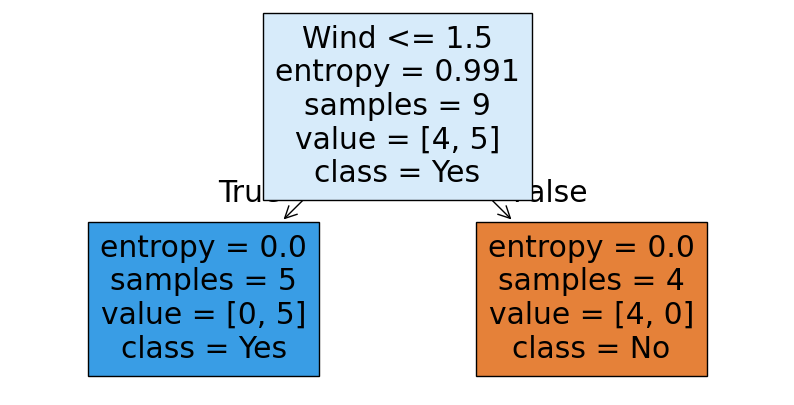

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plot_tree(dt, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

# Predict and Evaluate

In [23]:

y_pred = dt.predict(X_test)
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
results['Status'] = results.apply(lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1)
display(results)
print('\nAccuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

,Actual,Predicted,Status
0,1,1,Correct
1,1,1,Correct
2,0,1,Wrong
3,1,1,Correct
4,1,1,Correct



Accuracy: 0.8

Confusion Matrix:
 [[0 1]
 [0 4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.80      1.00      0.89         4

    accuracy                           0.80         5
   macro avg       0.40      0.50      0.44         5
weighted avg       0.64      0.80      0.71         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Classify a New Sample & Answer Queries

In [28]:
sample = pd.DataFrame({
    'Weather':['Sunny'],
    'Temperature':['Mild'],
    'Humidity':['High'],
    'Wind':['Breezy']
})

# encode sample using same encoders
encoded_sample = sample.copy()
for col in encoded_sample.columns:
    encoded_sample[col] = encoders[col].transform(encoded_sample[col])

prediction = dt.predict(encoded_sample)
label = encoders['GoForPicnic'].inverse_transform(prediction) # Changed 'PlayTennis' to 'GoForPicnic'
print('Prediction for sample:', label[0])

Prediction for sample: Yes
